In [1]:
import os
import sys
import json
import shutil
import pickle
import importlib
import itertools
import numpy as np
import pandas as pd
import nibabel as nib

sys.path.append('/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/')
import gen, t1
import bids_naming as names
import dataChecks as check

import visUtils, ptSelect

import projectUtils as prjUtils


In [2]:
# parameters
analysis_params = {
    
    #'time': str(gen.fmt_now()), # for file naming
    'time': '13Mar2026-1810', # for file naming
    #'mapDate': '12Feb2026-1304', # date of map creation, for finding the appropriate maps; Only used if not running stitch
    
    'test':False,
    'test_n':5,
    'override': False,
    'verbose': True,
    'demographics_pth': '/host/verges/tank/data/daniel/00_commonUtils/01_demographics/02_combined/demographics_25Feb2026-140252_sex.csv',
    'qMap_names':["T1map"], # names of qMAP of interest

    'ctrl_grp':"CTRL_match", # reference to Z score on
    'test_grps': ["TLE_L", "TLE_R"], # groups to compare to reference for Z score (excluding the ctrl_grp)

    'checkQC': True,
    'QCcsv_pth': None, # csv with quality ratings of volumes/surfaces for each session
    'pni_resolution':(0.5, 0.5, 0.5),  # target resolution for PNI 7T scans
    'min_age_thresh': 18, # exclude below
    'max_age_thresh': None, # exclude above
    'required_demo_cols': ['age', 'sex'], # exclude rows if missing values in these

    'SESchoice_method': 'first', # see ptSelect.clean_ses()

    'match_age_sex': True,
    'match_method': ['NearestNeighbour',4], # method and corresponding parameter

    'icFlip': True,
    'ipsiTo': 'L',
    
    'nSurfs':16,
    'smoothing':["0", "0p5"],
    'computeRawStats': True, # whether to compute stats on raw map values

    'equiVol_str': "equivol",
    'lbls_surfs': { # [ctx, hipp]
                    'pipelineNames': ['micapipe', 'hippunfold'],
                    'labels': [['pial', 'inner'],
                            ['white', 'outer']],
                    'surfaces': [['fsLR-32k', 'den-0p5mm']]
                    }
}

varsOfInterest = ['UID', 'MICS_ID', 'PNI_ID', 'study', 'SES', 'Date', 'age', 'sex', 'eth', 'gender', 'hand', 'edu', 'job', 'grp', 'grp_detailed','lastsz','numsurgicalresections','histopathology','ilaeoutcome1yr', 'engel6mo', 'focuslat', 'drugresistant']

dirs_project = {
    'dir_root': '/host/verges/tank/data/daniel/04_inVivoHistology',
    'dir_data': 'data/',
    'dir_out': 'outputs/',
    'demo_dfs': 'demo_dfs'
}

surf_mask_info = {
    'perform': True,
    'dir_root': '/host/verges/tank/data/daniel/04_inVivoHistology/code/resources',
    'maskName': 'Mesial Temporal Mask',
    'maskSuffix': 'mTemp',
    'surf_stitch_template': "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/templates/overlap_stitch_template_JD_Jan2026.pkl",
    'surfs_stitched_mask': "ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026_mask-mTempClean.label.gii",
    'surfs_stitched_lbls': "labels_stitch_ctx-Destrieux_hipp-DK25_13Mar2026_mask-mTempClean.label.gii"
}

visualization_params = {
    'add_stitchedSurf': True,
    'add_sampledSurfs': True,

    'ctx_surf': "fsLR-32k",
    'hipp_surf': "den-0p5mm",
    
    'equiVol_str': "equivol",
    'mask':{
        'applied': True,
        'suffix': surf_mask_info['maskSuffix'],
    },
    'colour': {
        'do': False,
        'outer': 'red',
        'inner': 'blue'
    }
}

if analysis_params['test']:
    dirs_project['dir_data'] = os.path.join(dirs_project['dir_data'], 'test/')

# TODO. Consolidate these dicts with anaylsis_params['surfs']
mp_surfaces = {
    'surf': ['fsLR-32k'],
    'lbl': ['pial', 'white'],
}

hu_surfaces = {
    'surf': ['den-0p5mm'],
    'lbl': ['inner', 'outer'],
}
# ^^^^^


study_dicts = [
    { # MICS
        'studyName': 'MICs',
        'studyDescrip': '3T',
        'dir_root': '/data/mica3/BIDS_MICs/',
        'dir_raw': 'rawdata/',
        'dir_deriv': 'derivatives/',
        'dir_fs': 'freesurfer/',
        'dir_mp': 'micapipe_v0.2.0/',
        'dir_hu': 'hippunfold_v1.3.0/hippunfold/', # update to v2?
    },
    { # PNI
        'studyName': 'PNI',
        'studyDescrip': '7T',
        'dir_root': '/data/mica3/BIDS_PNI/',
        'dir_raw': 'rawdata/',
        'dir_deriv': 'derivatives/',
        'dir_fs': 'fastsurfer/',
        'dir_mp': 'micapipe_v0.2.0/',
        'dir_hu': 'hippunfold_v1.3.0/hippunfold/', # update to v2?

        'dir_root_pilot': '/host/verges/tank/data/MICA-7T-pilot/',
        'dir_deriv_pilot': 'derivatives/',
        'dir_mp_pilot': 'micapipe/',
    }
]
hemis = ['L', 'R']
# create a json file of all these parameters for record keeping
gen.save_vars_to_json(filepath=os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], f"analysisParams_{analysis_params['time']}.json"))

[INFO] Saved variables (22KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/analysisParams_13Mar2026-1810.json


In [8]:
# input: demographics datasheet
demo = pd.read_csv(analysis_params['demographics_pth'])
print(f"Input demographics {demo.shape}: {demo.columns.tolist()}")

# Ensure data, SES properly formatted
demo['SES'] = demo['SES'].apply(lambda x: f'0{x}' if (isinstance(x, int) and x < 10) or (isinstance(x, str) and x.isdigit() and int(x) < 10) else str(x))
demo['Date'] = pd.to_datetime(demo['Date'], format='%d.%m.%Y', errors='coerce')

demo_subset = demo[varsOfInterest]

print(f"Shortened demographics: {demo_subset.shape}: {demo_subset.columns.tolist()}")
demo_subset.head()

Input demographics (897, 49): ['UID', 'MICS_ID', 'PNI_ID', 'study', 'SES', 'Date', 'sex', 'eth', 'job', 'edu', 'date_7t', 'lastsz', 'gender', 'dob', 'language', 'hand', 'date_3t', 'numasmonadmission', 'epilepsydxilae', 'invasiveexplorations', 'asmsonadmission', 'fdgpet', 'neuromoddevices', 'date_first_7t', 'numasmsprior', 'ilaeoutcome1yr', 'engel6mo', 'histopathology', 'prevasms', 'emuadmissiondate', 'numsurgicalresections', 'engel1yr', 'admissionduration', 'drugresistant', 'age_first_7t', 'date_first_3t', 'epilepsyclass', 'focuslat', 'baselinemri', 'surgicalresectiondatesite', 'focusconfirmed', 'epilepsyriskfactors', 'age_first_3t', 'Date_firstStudyScan', 'Age_firstStudyScan', 'age_fromFirstScan', 'age', 'grp', 'grp_detailed']
Shortened demographics: (897, 22): ['UID', 'MICS_ID', 'PNI_ID', 'study', 'SES', 'Date', 'age', 'sex', 'eth', 'gender', 'hand', 'edu', 'job', 'grp', 'grp_detailed', 'lastsz', 'numsurgicalresections', 'histopathology', 'ilaeoutcome1yr', 'engel6mo', 'focuslat', 'dr

,UID,MICS_ID,PNI_ID,study,SES,Date,age,sex,eth,gender,...,job,grp,grp_detailed,lastsz,numsurgicalresections,histopathology,ilaeoutcome1yr,engel6mo,focuslat,drugresistant
0,UID0001,NaN,Pilot007,7T,01,2022-03-11,NaN,M,NaN,NaN,...,NaN,CTRL,CTRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,UID0002,NaN,Pilot011,7T,05,2024-03-28,NaN,F,NaN,NaN,...,Full time student,CTRL,CTRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UID0003,NaN,Pilot012,7T,05,2024-04-11,NaN,F,NaN,NaN,...,Full time student,CTRL,CTRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,UID0004,HC129,Pilot013,7T,05,2024-04-18,27.78,F,Canadian,NaN,...,Full time student,CTRL,CTRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,UID0004,HC129,Pilot013,3T,01,2024-07-09,28.00,F,Canadian,NaN,...,NaN,CTRL,CTRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# QC checks
if analysis_params['checkQC']:
    importlib.reload(gen)
    importlib.reload(names)
    importlib.reload(check)
    qc_cols = []

    # extract 7T cases only
    sT_pt = demo_subset[demo_subset['PNI_ID'].isna()==False]
    sT_sessions = sT_pt[sT_pt['study'] == '7T']
    print(f'Number of 7T sessions: {len(sT_sessions)}')
    #print(sT_sessions.head())
    
    print("CHECKING DATA...")
    print(f"\t VOLUMES existence...")
    PNI = [s for s in study_dicts if s['studyName'] == 'PNI'][0]
    demo_volCheck, cols_volChk = check.vol_check(PNI, sT_sessions, analysis_params['qMap_names'], verbose=analysis_params['verbose'])
    qc_cols += cols_volChk

    print(f"\t RESOLUTION match {analysis_params['pni_resolution']}...")
    demo_res, res_dictList, cols_resChk = check.resolution_check(demo = demo_volCheck, 
                                                                 study = PNI, 
                                                                 res_trgt = analysis_params['pni_resolution'], 
                                                                 epsilon=0.001, verbose = analysis_params['verbose'])
    qc_cols += cols_resChk

    print(f"\t SURFACES present...")
    demo_volSurf_check, cols_procChk = check.proc_check(demo = demo_res, 
                                                        study = PNI, 
                                                        mp_surfaces = mp_surfaces, hu_surfaces = hu_surfaces,
                                                        verbose=analysis_params['verbose'])
    qc_cols += cols_procChk

    # check QC of surfaces and volumes (ie. properly fit surfaces, minimal artifacts in volumes)
    # TODO.

    print(f"\t AGE thresholds (min:{analysis_params['min_age_thresh']}, max:{analysis_params['max_age_thresh']})...")
    if analysis_params['min_age_thresh'] is not None:
        age_min_qc_col = f"age_above-{analysis_params['min_age_thresh']}"
        demo_volSurf_check[age_min_qc_col] = demo_volSurf_check['age'] >= analysis_params['min_age_thresh']
        qc_cols += [age_min_qc_col]
    if analysis_params['max_age_thresh'] is not None:
        age_max_qc_col = f"age_below-{analysis_params['max_age_thresh']}"
        demo_volSurf_check[age_max_qc_col] = demo_volSurf_check['age'] <= analysis_params['max_age_thresh']
        qc_cols += [age_max_qc_col]

    # missing demographic values
    missing_required_col = 'hasVars_demographics'
    demo_volSurf_check[missing_required_col] = ~demo_volSurf_check[analysis_params['required_demo_cols']].isna().any(axis=1)
    qc_cols += [missing_required_col]

    # save
    save_pth = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], f'demo_QCcols_{analysis_params["time"]}')
    save_item = [demo_volSurf_check, qc_cols]
    demo_volSurf_check.to_csv(save_pth + ".csv", index=False)
    with open(f"{save_pth}.json", "w") as f:
        json.dump(qc_cols, f, indent=2)
    print(f"Saved DataFrame to: {save_pth}.csv")
    print(f"Saved QC columns list to: {save_pth}.json")


Number of 7T sessions: 221
CHECKING DATA...
	 VOLUMES existence...
	Adding volume check column: hasVol_T1map
		Missing volume | Pilot007-01 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-Pilot007/ses-01/maps/sub-Pilot007_ses-01_space-nativepro_map-T1map.nii.gz


/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[col_name] = True


		Missing volume | PNC008-01 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-PNC008/ses-01/maps/sub-PNC008_ses-01_space-nativepro_map-T1map.nii.gz
		Missing volume | PNC032-a3 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-PNC032/ses-a3/maps/sub-PNC032_ses-a3_space-nativepro_map-T1map.nii.gz
		Missing volume | PNE002-a1 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-PNE002/ses-a1/maps/sub-PNE002_ses-a1_space-nativepro_map-T1map.nii.gz
		Missing volume | PNE007-a3 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-PNE007/ses-a3/maps/sub-PNE007_ses-a3_space-nativepro_map-T1map.nii.gz
		Missing volume | PNE032-a1 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-PNE032/ses-a1/maps/sub-PNE032_ses-a1_space-nativepro_map-T1map.nii.gz
		Missing volume | PNE050-a1 can't find: /host/verges/tank/data/MICA-7T-pilot/derivatives/micapipe/sub-PNE050/ses-a1/maps/sub-PNE050_se

/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[col_name] = demo[col_name].astype(bool)
/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[col_name] = True


	 RESOLUTION match (0.5, 0.5, 0.5)...
	File does not exist	| Pilot007-01: /data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-Pilot007/ses-01/maps/sub-Pilot007_ses-01_space-nativepro_map-T1map.nii.gz
	File does not exist	| PNC008-01: /data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC008/ses-01/maps/sub-PNC008_ses-01_space-nativepro_map-T1map.nii.gz
	File does not exist	| PNC032-a3: /data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC032/ses-a3/maps/sub-PNC032_ses-a3_space-nativepro_map-T1map.nii.gz
	File does not exist	| PNE002-a1: /data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNE002/ses-a1/maps/sub-PNE002_ses-a1_space-nativepro_map-T1map.nii.gz
	File does not exist	| PNE007-a3: /data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNE007/ses-a3/maps/sub-PNE007_ses-a3_space-nativepro_map-T1map.nii.gz
	File does not exist	| PNE032-a1: /data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNE032/ses-a1/maps/sub-PNE032_ses-a1_space-nativepro_map-T1map.nii.gz
	File does not

/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:122: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[col_name] = demo[col_name].astype(bool, errors='ignore') # convert to boolean, but keep 'NA' as is
/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[col] = False
/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:162: SettingWithCopyWarning: 
A value is trying to be set on

	 SURFACES present...
	Neither L nor R surface file exists	| ('/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-Pilot007/ses-01/surf/sub-Pilot007_ses-01_hemi-L_space-nativepro_surf-fsLR-32k_label-pial.surf.gii', '/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-Pilot007/ses-01/surf/sub-Pilot007_ses-01_hemi-R_space-nativepro_surf-fsLR-32k_label-pial.surf.gii')
	Neither L nor R surface file exists	| ('/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-Pilot007/ses-01/surf/sub-Pilot007_ses-01_hemi-L_space-nativepro_surf-fsLR-32k_label-white.surf.gii', '/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-Pilot007/ses-01/surf/sub-Pilot007_ses-01_hemi-R_space-nativepro_surf-fsLR-32k_label-white.surf.gii')
	Neither L nor R surface file exists	| ('/data/mica3/BIDS_PNI/derivatives/hippunfold_v1.3.0/hippunfold/sub-Pilot007/ses-01/surf/sub-Pilot007_ses-01_hemi-L_space-T1w_den-0p5mm_label-hipp_inner.surf.gii', '/data/mica3/BIDS_PNI/derivatives/hippunfold_v1.3.0/hippunfold/sub-Pilot007/s

/host/verges/tank/data/daniel/00_commonUtils/00_code/genUtils/dataChecks.py:182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[cols_added] = demo[cols_added].astype(bool)
/tmp/ipykernel_2579410/3266342333.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_volSurf_check[age_min_qc_col] = demo_volSurf_check['age'] >= analysis_params['min_age_thresh']
/tmp/ipykernel_2579410/3266342333.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [10]:
# CLEAN
importlib.reload(check)

reimport = False
if "demo_volSurf_check" not in locals() or reimport:
    common_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/outputs/demo_QCcols_26Feb2026-1503"
    demo_volSurf_check = pd.read_csv(f"{common_pth}.csv")
    qc_cols = json.load(open(f"{common_pth}.json"))
    print(f"Loaded DataFrame from: {common_pth}.csv")
    print(f"Loaded QC columns list from: {common_pth}.json")

# remove rows failing QC
qc_cols_present = [col for col in qc_cols if col in demo_volSurf_check.columns]
demo_qc, rm_rows = check.filter_qcCols(demo_volSurf_check, qc_cols)
rm_reasons = check.print_qcRemoval(rm_rows)

save_path = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'])

demo_qc.to_csv(os.path.join(save_path, f"demo_QC_retained_{analysis_params['time']}.csv"), index=False)
rm_rows.to_csv(os.path.join(save_path, f"demo_QC_failedRows_{analysis_params['time']}.csv"), index=False)
print(f"Saved cleaned df and removed rows in the directory: {save_path}")
# NOTE. Cases recently scanned may not yet be in clinical data sheet and thus age is likely missing.

[filter_qcCols] 50 rows (41 unique participants) removed when filtering QC cols: ['hasVol_T1map', 'properRes', 'mp_proc_pial_fsLR-32k', 'mp_proc_white_fsLR-32k', 'hu_proc_inner_den-0p5mm', 'hu_proc_outer_den-0p5mm', 'age_above-18', 'hasVars_demographics']
Total UID: 43
[print_qcRemoval] 50 rows removed (43 unique participants). Breakdown by primary reason:
	Missing volumes (hasVol_*): 8 rows
		['UID0001-nan-Pilot007@7T-01', 'UID0021-nan-PNC008@7T-01', 'UID0045-nan-PNC032@7T-a3', 'UID0054-PX183-PNE002@7T-a1', 'UID0059-PX158-PNE007@7T-a3', 'UID0093-PX234-PNE032@7T-a1', 'UID0115-PX250-PNE050@7T-a1', 'UID0123-PX132-PNE055@7T-a1']
	Improper resolution (properRes): 1 rows
		['UID0127-nan-PNE059@7T-a1']
	Missing HippUnfold processing (hu_*): 14 rows
		['UID0128-nan-PNA011@7T-a1', 'UID0129-HC077-PNC048@7T-a1', 'UID0130-PX265-PNE060@7T-a1', 'UID0131-PX226-PNE061@7T-a1', 'UID0134-HC141-PNC049@7T-a1', 'UID0135-PX269-PNE064@7T-a1', 'UID0136-nan-PNE065@7T-a1', 'UID0137-nan-PNE066@7T-a1', 'UID0138-P

In [ ]:
# MAKE DF BY GROUP
importlib.reload(t1)
importlib.reload(ptSelect)

print(f"demo_qc shape: {demo_qc.shape}")

# create dfs by group
grp_col = 'grp_detailed'
groups = ["CTRL", "TLE_L", "TLE_R"]
list_df_groups = []
for idx, grp in enumerate(groups):
    df_in = demo_qc[demo_qc[grp_col] == grp]
    list_df_groups.append((grp, df_in))
    
    if grp == 'CTRL':
        list_df_groups_ctrl_idx = idx

    if grp in ['TLE_L', 'TLE_R']:
        list_df_groups_tle_idx = list_df_groups_tle_idx + [idx] if 'list_df_groups_tle_idx' in locals() else [idx]

# merge TLE_L and TLE_R
df_TLE_LR = None
for idx in list_df_groups_tle_idx:
    df_in = list_df_groups[idx][1]
    if df_TLE_LR is not None:
        df_TLE_LR = pd.concat([df_TLE_LR, df_in], ignore_index=True)
    else:
        df_TLE_LR = df_in

list_df_groups.append(('TLE_LR', df_TLE_LR))
list_df_groups_tle_LR_idx = (len(list_df_groups) - 1)

all_raw_stats = t1.summarize_grps(list_df_groups, 
    out_path = os.path.join(dirs_project['dir_root'], dirs_project['dir_out']), 
    name_append=f"multisessions_{analysis_params['time']}")

# 1. CHOOSE UNIQUE SESSION PER INDIVIDUAL
list_groups_clean = []
for idx, df_grp in enumerate(list_df_groups):
    list_groups_clean.append(ptSelect.clean_ses(df_grp, method=analysis_params['SESchoice_method']))

# 2. MATCH GROUPS
if analysis_params['match_age_sex']:
    ctrl_mtch_idx = ptSelect.psm_match(df_ctrl = list_groups_clean[list_df_groups_ctrl_idx][1], 
                                        df_test = list_groups_clean[list_df_groups_tle_LR_idx][1],
                                        matching_method=analysis_params['match_method'][0], k_nn=analysis_params['match_method'][1],)

    df_ctrl_matched = list_groups_clean[list_df_groups_ctrl_idx][1].loc[list_groups_clean[list_df_groups_ctrl_idx][1]['UID'].isin(ctrl_mtch_idx)]
    list_groups_ctrlMatch = list_groups_clean.copy()
    list_groups_clean.append(['CTRL_match', df_ctrl_matched])

    stats_name = "TLE_CTRL_matched"
else:
    stats_name = "TLE_CTRL_cleanSES"

# SAVE DEMOGRAPHICS, CREATE DICT ITEMS PER GROUP
grp_dicts = []
out_path = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], dirs_project['demo_dfs'])
prjUtils.make_dir(out_path)

ids_all_fmt = []
df_all = pd.DataFrame()
for grp, df in list_groups_clean:
    
    demo_list = []
    for idx, row in df.iterrows():
        mics_id = row['MICS_ID'] if pd.notna(row['MICS_ID']) else 'nan'
        pni_id = row['PNI_ID'] if pd.notna(row['PNI_ID']) else 'nan'
        id_fmt = f"{row['UID']}@{row['study']}-{mics_id}-{pni_id}-{row['SES']}"
        demo_list.append(id_fmt)
    
    print(f"{grp} | {df['UID'].nunique()} participants ({df.shape[0]} sessions) retained: {demo_list}")

    save_path = t1.get_sumStats_outName(path=out_path,
                                    name_append=f"{grp}_{analysis_params['time']}", ext='csv')
    df.to_csv(save_path, index=False)
    print(f"Saved demographics for group {grp}: {save_path}")
    dict_item = {
        'analysis_time': analysis_params['time'],
        'group': grp,
        'demo_df_pth': save_path,
        'n_unique': df['UID'].nunique(),
        'n_SES': df.shape[0],
        'IDs': demo_list
    }

    grp_dicts.append(dict_item)

    # build a list for all participants
    df_all = pd.concat([df, df_all])
    ids_all_fmt.append(demo_list)

list_groups_clean.append(['all', df_all])
df_all_save_path = t1.get_sumStats_outName(path=out_path,
                                    name_append=f"all_{analysis_params['time']}", ext='csv')
df_all.to_csv(df_all_save_path, index=False)
print(f"Saved demographics for all participants used in this analysis: {df_all_save_path}")
dict_item_all = {
        'analysis_time': analysis_params['time'],
        'group': 'all',
        'demo_df_pth': df_all_save_path,
        'n_unique': df_all['UID'].nunique(),
        'n_SES': df_all.shape[0],
        'IDs': ids_all_fmt
    }
grp_dicts.append(dict_item_all)

# SAVE SUMMARY STATS BY GROUP
# Save grp_dicts as JSON
grp_dicts_save_path = os.path.join(dirs_project['dir_root'], dirs_project['dir_out'], f"grp_dicts_{analysis_params['time']}.json")
with open(grp_dicts_save_path, 'w') as f:
    json.dump(grp_dicts, f, indent=4)
print(f"Saved list of group dictionaries to: {grp_dicts_save_path}")

stats = t1.summarize_grps(list_groups_clean)
stats_save_path = t1.get_sumStats_outName(path=os.path.join(dirs_project['dir_root'], dirs_project['dir_out']), 
                                         name_append=f"{stats_name}_{analysis_params['time']}")

stats.to_csv(stats_save_path, index=False)
print(f"Saved stats table to: {stats_save_path}")
stats

demo_qc shape: (171, 30)
[t1.summarize_grps]:
	Grp CTRL    | 46 unique participants with 103 sessions
	Grp TLE_L   | 10 unique participants with 12  sessions
	Grp TLE_R   | 10 unique participants with 12  sessions
	Grp TLE_LR  | 20 unique participants with 24  sessions
	Saved summary stats to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/summaryStats_multisessions_13Mar2026-1810.csv
CTRL | n unique: 46, n sessions: 103, 22 repeated participants
	UID0014@7T | ['02', '01'] -> 01
	UID0015@7T | ['01', '02', '03'] -> 01
	UID0016@7T | ['01', '03', '02', '04'] -> 01
	UID0017@7T | ['01', '02', '03'] -> 01
	UID0018@7T | ['02', '01'] -> 01
	UID0019@7T | ['02', '01', '04', '03'] -> 01
	UID0020@7T | ['02', '03', '01', '04'] -> 01
	UID0022@7T | ['01', '03', '02', '04', 'a1'] -> 01
	UID0023@7T | ['02', '03', '01'] -> 01
	UID0024@7T | ['03', '04', '01', '02'] -> 01
	UID0026@7T | ['02', '01', '04'] -> 01
	UID0028@7T | ['03', '02', '04', '01'] -> 01
	UID0029@7T | ['02', '01', '03', '04'] ->

,Group,n_unique,n_SES,Sex_percF,Sex_F,Sex_M,Age_min,Age_25p,Age_mean,Age_median,Age_75p,Age_max,Age_std,Age_IQR
0,CTRL,46.0,46.0,52.173913,24.0,22.0,20.2,26.500,29.530000,27.95,31.475,42.8,5.362228,4.975
1,TLE_L,10.0,10.0,50.000000,5.0,5.0,29.8,30.750,36.510000,32.65,36.500,61.2,9.687730,5.750
2,TLE_R,10.0,10.0,90.000000,9.0,1.0,20.4,24.100,34.120000,33.65,42.925,49.7,10.824335,18.825
3,TLE_LR,20.0,20.0,70.000000,14.0,6.0,20.4,30.400,35.315000,32.65,42.175,61.2,10.072698,11.775
4,CTRL_match,30.0,30.0,53.333333,16.0,14.0,24.5,26.950,31.116667,29.70,34.550,42.8,5.546735,7.600
5,all,66.0,116.0,57.575758,38.0,28.0,20.2,26.825,31.283030,29.45,34.550,61.2,7.532628,7.725


In [13]:
# MAKE MAPS FROM APPROPRIATE EQUIVOLUMETRIC SURFACES

importlib.reload(prjUtils)

if analysis_params['test']:
    # take random sample of test_n subjects
    df_all = df_all.sample(n=analysis_params['test_n'])

    # take specific row: 
    #demo_qc = demo_qc.loc[demo_qc['PNI_sID'] == 'PNC021']

    print(f"TEST MODE: {analysis_params['test_n']} rows kept:")
    for idx, row in df_all.iterrows():
        print(f"\t{row['UID']}@{row['study']}: {row['MICS_ID']}-{row['PNI_ID']}-{row['SES']}")

# STITCH
surfs_stitched, date = prjUtils.stitch_surfs_from_df(dirs_project = dirs_project, study_dicts = study_dicts, 
                              df = df_all, 
                              lbls_surfs = analysis_params['lbls_surfs'], 
                              date = analysis_params['time'],
                              symlink=True)
analysis_params['mapDate'] = date

# MASK
surfs_mask = prjUtils.apply_mask_toStitchedSurfaces(surf_pths = surfs_stitched, 
                                                    mask_pth = os.path.join(surf_mask_info['dir_root'], surf_mask_info['surfs_stitched_mask']), 
                                                    outNameSuffix=surf_mask_info['maskSuffix'], override=analysis_params['override'])

# EQUIVOL SURFS
prjUtils.sample_stitchedSurfs_from_df(df=df_all, study_dicts=study_dicts, dirs_project=dirs_project, 
                                      nSurfs=analysis_params['nSurfs'],
                                      ctx_surf="fsLR-32k", 
                                      hipp_surf="den-0p5mm", 
                                      mask_info = surf_mask_info, 
                                      str_append=date, verbose=True)

# SAMPLE AND SMOOTH
prjUtils.surf_to_map_from_df(df=df_all,
                            study_dicts=study_dicts,
                            dirs_project=dirs_project,
                            analysis_params=analysis_params,
                            date = date,
                            verbose=True)

[stitch_surfs_from_df] Stitching surfaces for 116 rows (unique participant-study-session)...
	UID0027@7T: PNC014-01
	[stitch_surfs_from_df] Stitched surfaces already exist for [ctx] fsLR-32k_pial and [hipp] den-0p5mm_inner -> /host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNC014_ses-01/surfs/sub-PNC014_ses-01_hemi-L_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026-1810.surf.gii | /host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNC014_ses-01/surfs/sub-PNC014_ses-01_hemi-R_ctxSurf-fsLR-32k_ctxLbl-pial_hippSurf-den-0p5mm_hippLbl-inner_stitched_13Mar2026-1810.surf.gii. Skipping stitching.
	[stitch_surfs_from_df] Stitched surfaces already exist for [ctx] fsLR-32k_white and [hipp] den-0p5mm_outer -> /host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNC014_ses-01/surfs/sub-PNC014_ses-01_hemi-L_ctxSurf-fsLR-32k_ctxLbl-white_hippSurf-den-0p5mm_hippLbl-outer_stitched_13Mar2026-1810.surf.gii | /host/verges/tank/data/daniel/0

In [ ]:
# AGGREGATE MAPS BY GROUP
importlib.reload(prjUtils)
prjUtils.aggregateMap_loop(analysis_params, dirs_project, grp_dicts, study_dicts) # NOTE. NOT TESTED SINCE MOVED TO prjUtils

surf:1/16, smth:0
	CTRL | 46 rows
		Aggregated maps files already present and `override` is False. Skipping aggregation.
		CTRL | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/CTRL
	TLE_L | 10 rows
		Aggregated maps files already present and `override` is False. Skipping aggregation.
		TLE_L | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_L
	TLE_R | 10 rows
		Aggregated maps files already present and `override` is False. Skipping aggregation.
		TLE_R | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_R
	TLE_LR | 20 rows
		Aggregated maps files already present and `override` is False. Skipping aggregation.
		TLE_LR | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Mar2026-1810/TLE_LR
	CTRL_match | 30 rows
		Aggregated maps files already present and `override` is Fa

In [157]:
# COMPUTE MOMENTS and GRADIENTS
importlib.reload(prjUtils)
pkl_pths = []
moment_pths = []
gradient_pths = []
for grp_dict, mapName, smth, hemi in itertools.product(grp_dicts, analysis_params['qMap_names'], analysis_params['smoothing'], hemis):
    grp = grp_dict['group']
    if grp == 'all': # skip
        continue

    print(f"{'='*40}\n{grp} | {mapName} - {smth}mm [{hemi}]")
    
    # Concat data across surfaces levels
    _, pkl_pth = prjUtils.make_3D_array_lvlBYptBYvrtx(grp, hemi, mapName, smth, analysis_params, dirs_project)
    pkl_pths.append(pkl_pth)
    
    # compute and save:
    # A. Moments
    _, moment_path = prjUtils.save_moments_from_pickleBundle(bundle_path=pkl_pth, 
                                                     dirs_project=dirs_project,
                                                     verbose = analysis_params['verbose'], override=analysis_params['override'])
    moment_pths.append(moment_path)

    # B. Gradients
    _, gradients_path = prjUtils.save_gradients_from_pickleBundle(bundle_path=pkl_pth, 
                                                    dirs_project=dirs_project,
                                                    verbose = analysis_params['verbose'], override=analysis_params['override'])
    gradient_pths.append(gradients_path)

# B.1 Align gradients
aligned_gradient_pths = prjUtils.align_gradients_loop(grp_dicts, analysis_params, dirs_project, 
                                                       grp_align_to = analysis_params['ctrl_grp'])


# Z-score
importlib.reload(prjUtils)
moment_z_paths = prjUtils.get_z_for_3D_array(analysis_params, dirs_project, stat_name = 'moments')
gradient_z_paths = prjUtils.get_z_for_3D_array(analysis_params, dirs_project, stat_name = 'gradients')

# IC flip & combine ipsi/contra maps within disease types (i.e., TLE)
# TODO. Improve method of creating `statNames` list
importlib.reload(prjUtils)
statNames = ['moments', 'moments-z', 'gradients', 'gradients-z']
prjUtils.icFlip(grp_dicts, analysis_params, dirs_project, statNames =statNames )
out_pths_data_raw, out_pths_data_z = prjUtils.combine_ic_all_corresp_grps(analysis_params, dirs_project, statNames=statNames)

CTRL | T1map - 0mm [L]
	[make_3D_array_lvlBYptBYvrtx]
		Reading in arrays (.parquet) of PT by VRTX for each surface level. Saving as 3D array. Returning save path and data
		Skipping. File already exists.
	[get_moment_from_pickleBundle]
		Not overriding existing file.
	[save_gradients_from_pickleBundle]
		Not overriding existing file.
CTRL | T1map - 0mm [R]
	[make_3D_array_lvlBYptBYvrtx]
		Reading in arrays (.parquet) of PT by VRTX for each surface level. Saving as 3D array. Returning save path and data
		Skipping. File already exists.
	[get_moment_from_pickleBundle]
		Not overriding existing file.
	[save_gradients_from_pickleBundle]
		Not overriding existing file.
CTRL | T1map - 0p5mm [L]
	[make_3D_array_lvlBYptBYvrtx]
		Reading in arrays (.parquet) of PT by VRTX for each surface level. Saving as 3D array. Returning save path and data
		Skipping. File already exists.
	[get_moment_from_pickleBundle]
		Not overriding existing file.
	[save_gradients_from_pickleBundle]
		Not overriding ex

In [61]:
importlib.reload(prjUtils)

print(f"COMPUTING STATS ON MERGED Z-SCORES...") # for use in D scoring
for lvl, mapName, smth in itertools.product(range(1, analysis_params['nSurfs'] + 1), analysis_params['qMap_names'], analysis_params['smoothing']):
    print(f"surf:{lvl}/{analysis_params['nSurfs']}, smth:{smth}")
    
    for grp in [grpToSaveIn, analysis_params['ctrl_grp']]: # compute stats on merged z scores for patients and controls
    
        out_dir = prjUtils.get_aggregateMapDir(dirs_project, analysis_params['time'], grp=grp)
        if grp == grpToSaveIn and analysis_params['icFlip']:
            hemis = ['ipsi', 'contra']
        else:
            hemis = ['L', 'R']
            
        _,_ = prjUtils.aggregate_mapStats(dirs_project=dirs_project, 
                                grp=grp,
                                equiVol_str=analysis_params['equiVol_str'], 
                                lvl=lvl, 
                                nSurfs=analysis_params['nSurfs'],
                                mapName=mapName,
                                smth=smth,
                                analysisTime=analysis_params['time'],
                                out_dir=out_dir,
                                stats_name='z',
                                hemis=hemis,
                                visualize=False
                                )

COMPUTING STATS ON MERGED Z-SCORES...
surf:1/16, smth:0
		TLE_LR | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR
		CTRL_match | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/CTRL_match
surf:1/16, smth:0p5
		TLE_LR | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR
		CTRL_match | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/CTRL_match
surf:2/16, smth:0
		TLE_LR | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR
		CTRL_match | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/CTRL_match
surf:2/16, smth:0p5
		TLE_LR | Saved 8 stats maps in /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR
	

In [62]:
print(f"COMPUTING D-SCORES... ")
importlib.reload(prjUtils)
analysis_params['ipsiTo'] = analysis_params.get('ipsiTo', 'L')

for lvl, mapName, smth in itertools.product(range(1, analysis_params['nSurfs'] + 1), analysis_params['qMap_names'], analysis_params['smoothing']):
    print(f"{mapName} | surf:{lvl}/{analysis_params['nSurfs']} | smth:{smth}")

    _,_ = prjUtils.compute_cohensD(ctrl_name=analysis_params['ctrl_grp'],
                            test_name='TLE_LR',
                            dirs_project=dirs_project,
                            analysis_params=analysis_params,
                            lvl=lvl,
                            mapName=mapName,
                            smth=smth,
                            icFlip=analysis_params['icFlip'],
                            ipsiTo=analysis_params['ipsiTo'])


COMPUTING D-SCORES... 
T1map | surf:1/16 | smth:0
	[compute_cohensD] TLE_LR-CTRL_match | Saving outputs (ipsi/contra flipped hemis)...
		hemi-ipsi (42KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR-CTRL_match/group-TLE_LR-CTRL_match_hemi-ipsi_26Feb2026-1503_equivol-1of16_map-T1map_smth-0mm_stat-z_cohensD.func.gii
		hemi-contra (42KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR-CTRL_match/group-TLE_LR-CTRL_match_hemi-contra_26Feb2026-1503_equivol-1of16_map-T1map_smth-0mm_stat-z_cohensD.func.gii
T1map | surf:1/16 | smth:0p5
	[compute_cohensD] TLE_LR-CTRL_match | Saving outputs (ipsi/contra flipped hemis)...
		hemi-ipsi (42KB): /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR-CTRL_match/group-TLE_LR-CTRL_match_hemi-ipsi_26Feb2026-1503_equivol-1of16_map-T1map_smth-0p5mm_stat-z_cohensD.func.gii
		hemi-contra (42KB): /host/verges/tank/data/daniel/04_inVivoHis

In [63]:
# make summary feature maps: find corresponding maps per participant and comput statistics
importlib.reload(visUtils)
coords_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/"
ap_coords_lbl = os.path.join(coords_root, "stitch_lbl_AP_masked-13Feb2026.label.gii")

ap_coords = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lbl_AP_masked-13Feb2026.label.gii"
an_coords = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lbl_AlloNeo_masked-13Feb2026.label.gii"

# visualize dMap
root = "/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR-CTRL_match/"
for lvl, smth, hemi in itertools.product(range(1, analysis_params['nSurfs']-1), analysis_params['smoothing'], ['ipsi', 'contra']):
    visUtils.vis_make_unfold(feature_map_pth=f"{root}/group-TLE_LR-CTRL_match_hemi-{hemi}_26Feb2026-1503_equivol-{lvl}of16_map-T1map_smth-{smth}mm_stat-z_cohensD.func.gii",
                    unfold_x_coords_pth=an_coords,
                    unfold_y_coords_pth=ap_coords, 
                    map_name=f"Cohen's D - TLE-{hemi} v CTRL_mtch T1map ({lvl}/16, {smth}mm)", 
                    out_pth=os.path.join(root, f"group-TLE_LR-CTRL_match_hemi-{hemi}_26Feb2026-1503_equivol-{lvl}of16_map-T1map_smth-{smth}mm_stat-z_cohensD.png"),
                    vmin = -1.5,
                    vmax = 1.5,
                    cmap='bwr')


Number missing values: 0
Feature map data range (cleaned):
	min=-0.8847830891609192
	max=1.180570125579834
	mean=0.05425522103905678
	std=0.40217775106430054
	90% Perc=0.5520839691162109
	10% Perc=-0.48834702372550964
	IQR=0.6555776596069336
	Saved visualization to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR-CTRL_match/group-TLE_LR-CTRL_match_hemi-ipsi_26Feb2026-1503_equivol-1of16_map-T1map_smth-0mm_stat-z_cohensD.png
Number missing values: 0
Feature map data range (cleaned):
	min=-1.0485472679138184
	max=0.9886046051979065
	mean=-0.08117475360631943
	std=0.3364889919757843
	90% Perc=0.3538050055503845
	10% Perc=-0.5145480632781982
	IQR=0.4846746325492859
	Saved visualization to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/26Feb2026-1503/TLE_LR-CTRL_match/group-TLE_LR-CTRL_match_hemi-contra_26Feb2026-1503_equivol-1of16_map-T1map_smth-0mm_stat-z_cohensD.png
Number missing values: 3
Feature map data range (cleaned):
	

In [ ]:
# show collapsed view

Summary of Cohen's D values for hemi-R:
   Region hemi    Mean_D     Std_D N_nan      Vmin      Vmax       IQR  \
0      EC    R -0.105100  0.150841     0 -0.469814  0.398621  0.199147   
1    PreS    R -0.115805  0.274873     0 -1.149129  0.735652  0.255601   
2       H    R -0.070229  0.072327     2 -0.202172  0.015152  0.086674   
3    PeEc    R -0.181530  0.407996     0 -1.267274  0.583972  0.604806   
4    PHA1    R -0.095298  0.159923     0 -0.442588  0.286563  0.230639   
5    PHA3    R -0.196474  0.150811     0 -0.541752  0.261858  0.194278   
6      TF    R -0.346214  0.347061     0 -1.173481  0.472837  0.455668   
7    PHA2    R -0.020012  0.136314     0 -0.377572  0.400292  0.152923   
8     VVC    R -0.128825  0.236766     1 -0.624016  0.583112  0.263312   
9     Sub    R  0.331999  0.205226     0 -0.083995  0.768244  0.317893   
10    CA1    R -0.174949  0.206593     0 -0.576034  0.573152  0.324407   
11    CA2    R -0.304945  0.171445     0 -0.560871  0.377226  0.183382  

In [ ]:
resource_root = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/"
lbl_pth = "stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp.label.gii"
lbl_data = nib.load(os.path.join(resource_root, lbl_pth)).darrays[0].data
csv_pth = "stitch_lblValDetails_ctx-glsr_hipp-DK25_12Feb2026-0915.csv"
df_csv = pd.read_csv(os.path.join(resource_root, csv_pth))
label_col = 'SName'

data_root = "/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/"
d_l="cohenD_TLE_hemi-R_12Feb2026-1304.func.gii"
d_r="cohenD_TLE_hemi-L_12Feb2026-1304.func.gii"
data_l = nib.load(os.path.join(data_root, d_l)).darrays[0].data
data_r = nib.load(os.path.join(data_root, d_r)).darrays[0].data

table = pd.DataFrame(columns=['Region', 'hemi', 'Mean_D', 'Std_D', 'N_nan'])

# make a table with mean, std of D per region
for data, hemi in zip([data_l, data_r], ['R', 'L']):
    for label in np.unique(lbl_data):
        #print(label)
        region_name = df_csv[df_csv['idx'] == label][label_col]
        region_mask = lbl_data == label
        d_values_region = data[region_mask]
        # Filter out NaN values before computing mean
        d_values_region_clean = d_values_region[~np.isnan(d_values_region)]
        if len(d_values_region_clean) > 0:
            mean_d = np.mean(d_values_region_clean)
            std_d = np.std(d_values_region_clean)
            vmin = d_values_region_clean.min()
            vmax = d_values_region_clean.max()
            iqr = np.subtract(*np.percentile(d_values_region_clean, [75, 25]))
            tenPer = np.percentile(d_values_region_clean, 10)
            ninetyPer = np.percentile(d_values_region_clean, 90)
        else:
            mean_d = np.nan
            std_d = np.nan
            vmin = np.nan
            vmax = np.nan
            iqr = np.nan
            tenPer = np.nan
            ninetyPer = np.nan

        new_row = pd.DataFrame({
            'Region': [region_name.iloc[0] if len(region_name) > 0 else f'Label_{label}'],
            'hemi': [hemi],
            'Mean_D': [mean_d], 
            'Std_D': [std_d], 
            'N_nan': [np.sum(np.isnan(d_values_region))],
            'Vmin': [vmin],
            'Vmax': [vmax],
            'IQR': [iqr],
            '10th_Percentile': [tenPer],
            '90th_Percentile': [ninetyPer]
        })
        table = pd.concat([table, new_row], ignore_index=True)
    print(f"Summary of Cohen's D values for hemi-{hemi}:\n{table}\n")


# save 
save_rt = "/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/"
save_name = "CohenD_TLE_L_byRegion_13Feb2026.csv"
table.to_csv(os.path.join(save_rt, save_name), index=False)
print(f"Saved Cohen's D summary table by region to: {os.path.join(save_rt, save_name)}")

# for each region sharing the same name 'region' and in the same hemi, take average and return as new sheet
table_avg = table.groupby(['Region', 'hemi']).mean().reset_index()
table_avg.to_csv(os.path.join(save_rt, "CohenD_TLE_L_byRegion_avg_13Feb2026.csv"), index=False)
print(f"Saved averaged Cohen's D summary table by region to: {os.path.join(save_rt, 'CohenD_TLE_L_byRegion_avg_13Feb2026.csv')}")

In [ ]:
# D by label

(8477, 57) (8477, 32)
(8477, 57) (8477, 32)
	Saved t-test p-value map to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/ttestP_TLE_hemi-L_grp-TLE_12Feb2026-1304.func.gii
	Saved t-test t-value map to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/ttestT_TLE_hemi-L_grp-TLE_12Feb2026-1304.func.gii
	Saved t-test p-value map to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/ttestP_TLE_hemi-R_grp-TLE_12Feb2026-1304.func.gii
	Saved t-test t-value map to: /host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/ttestT_TLE_hemi-R_grp-TLE_12Feb2026-1304.func.gii


In [ ]:
# are patients and controls different - p-value via t-test 

data_root = "/host/verges/tank/data/daniel/04_inVivoHistology/outputs/group_maps/13Feb2026-T1map_lvl-8_smth-0p5/"
ctrl_l = "group-CTRL_hemi-L_12Feb2026-1304_equivol-8of16_map-T1map_smth-0p5_maps.pkl"
ctrl_r = "group-CTRL_hemi-R_12Feb2026-1304_equivol-8of16_map-T1map_smth-0p5_maps.pkl"

test_name = 'TLE'
tle_hemil = "group-TLE_BL_hemi-L_12Feb2026-1304_equivol-8of16_map-T1map_smth-0p5_maps.pkl"
tle_hemir = "group-TLE_BL_hemi-R_12Feb2026-1304_equivol-8of16_map-T1map_smth-0p5_maps.pkl"

# copmare vertices between ctrl and test using t-test, return p-value map
from scipy.stats import ttest_ind
dfs_out = []
for ctrl_pth, test_pth in zip([os.path.join(data_root, ctrl_l), os.path.join(data_root, ctrl_r)], 
                                [os.path.join(data_root, tle_hemil), os.path.join(data_root, tle_hemir)]):
    if not os.path.exists(ctrl_pth):
        print(f"Control file not found: {ctrl_pth}")
        continue
    if not os.path.exists(test_pth):
        print(f"Test file not found: {test_pth}")
        continue

    ctrl_data = pickle.load(open(ctrl_pth, 'rb'))
    tle_data = pickle.load(open(test_pth, 'rb'))
    print(ctrl_data.shape, tle_data.shape)
    
    # Perform t-test and get both t-values and p-values
    t_stats, p_values = zip(*[ttest_ind(tle_data[i], ctrl_data[i], equal_var=False) for i in range(ctrl_data.shape[0])])
    t_values = np.array(t_stats)
    p_values = np.array(p_values)
    
    dfs_out.append([ctrl_pth, test_pth, t_values, p_values])

# save as pickle
out_name = "13Feb2026_TLE_stats-p_maps.pkl"
with open(os.path.join(data_root, out_name), 'wb') as f:
    pickle.dump(dfs_out, f)

giis = []
for ctrl_pth, test_pth, t_values, p_values in dfs_out:
    hemi = 'L' if 'hemi-L' in ctrl_pth else 'R'
    out_name_p = f'ttestP_{test_name}_hemi-{hemi}_grp-TLE_{analysis_params['time']}.func.gii'
    out_name_t = f'ttestT_{test_name}_hemi-{hemi}_grp-TLE_{analysis_params['time']}.func.gii'
    out_pth_p = os.path.join(data_root, out_name_p)
    out_pth_t = os.path.join(data_root, out_name_t)
    
    gii = nib.GiftiImage()
    p_array = nib.gifti.GiftiDataArray(
        data=p_values.astype('float32'),
        intent='NIFTI_INTENT_PVAL'  # p-values
    )
    gii.add_gifti_data_array(p_array)
    nib.save(gii, out_pth_p)
    print(f"\tSaved t-test p-value map to: {out_pth_p}")
    
    gii = nib.GiftiImage()
    t_array = nib.gifti.GiftiDataArray(
        data=t_values.astype('float32'),
        intent=3  # t-values
    )
    gii.add_gifti_data_array(t_array)
    nib.save(gii, out_pth_t)
    print(f"\tSaved t-test t-value map to: {out_pth_t}")

    giis.append([out_pth_t, out_pth_p])
    


Number missing values: 0
Feature map data range (cleaned):
	min=118
	max=206
	mean=181.67913176831425
	std=21.866791473682714
	90% Perc=199.0
	10% Perc=135.0
	IQR=7.0


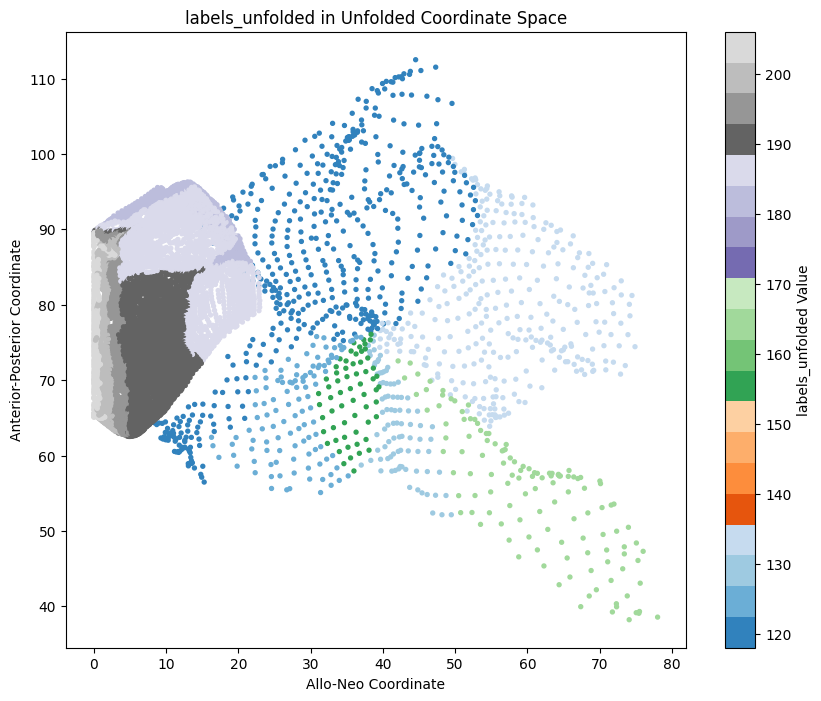

In [ ]:
# show the label for the surface on the unfolded space
visUtils.vis_make_unfold(unfold_x_coords_pth=an_coords, unfold_y_coords_pth=ap_coords, feature_map_pth=label_pth, map_name=f"labels_unfolded", cmap='tab20c')

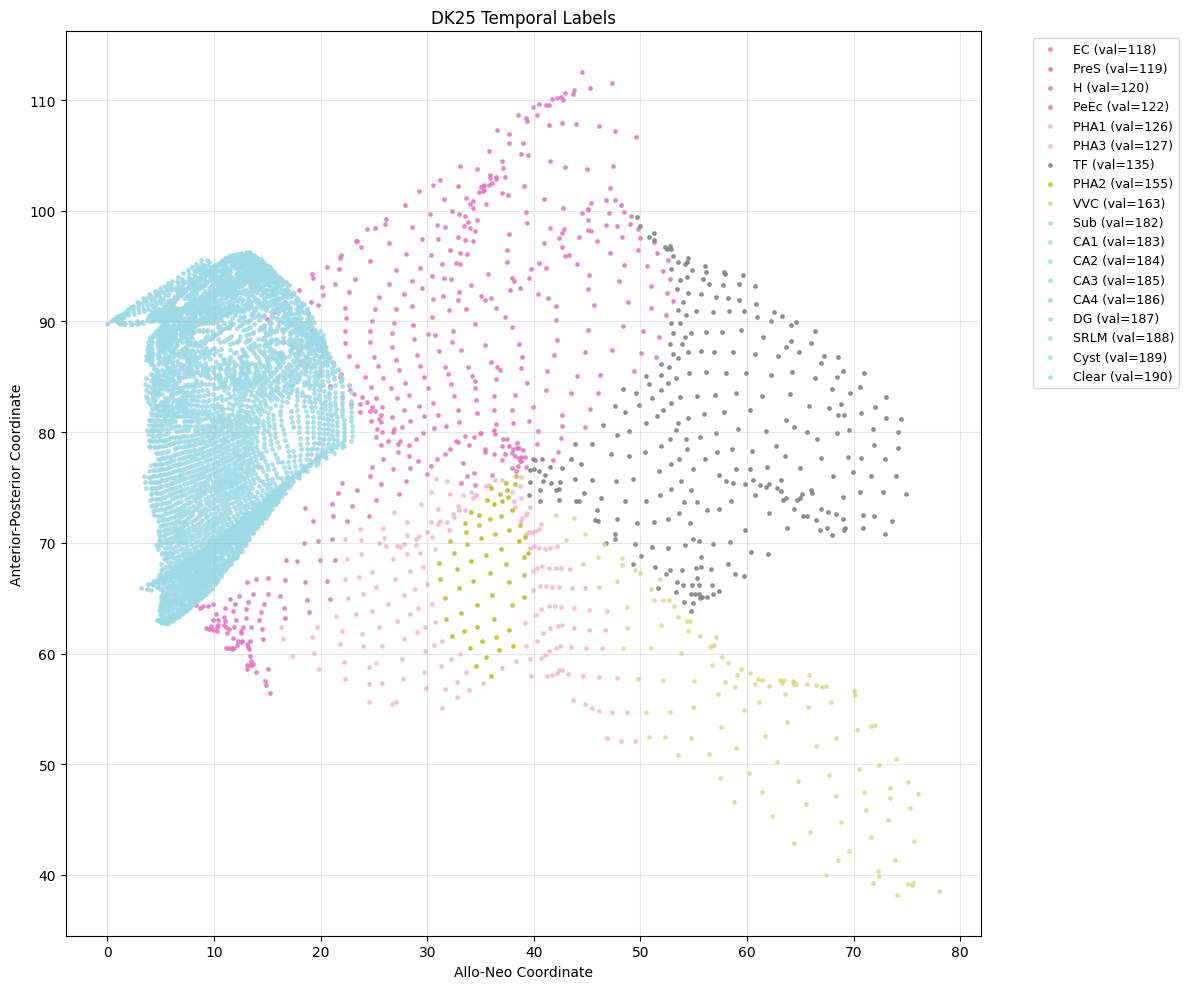

In [90]:
# gii_lbl

def visualize_label(unfold_x_coords_pth, unfold_y_coords_pth, feature_map_pth, lbl_csv_pth, 
                   lbl_value_col="LabelValue", lbl_name_col="SName", map_name="Labeled", cmap='tab20'):
    """Plot label values with SAME COLOR for duplicate text labels"""
    import nibabel as nib
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Load data
    x_coords = nib.load(unfold_x_coords_pth).darrays[0].data
    y_coords = nib.load(unfold_y_coords_pth).darrays[0].data
    feature_map = nib.load(feature_map_pth).darrays[0].data
    lbl_df = pd.read_csv(lbl_csv_pth)
    
    # Map TEXT NAMES → unique index for consistent coloring
    unique_text_names = lbl_df[lbl_name_col].unique()
    text_to_color_idx = {name: i for i, name in enumerate(unique_text_names)}
    
    # Create color map: same text = same color
    cmap_obj = plt.get_cmap(cmap)
    name_to_color = {name: cmap_obj(idx / len(unique_text_names)) 
                     for name, idx in text_to_color_idx.items()}
    
    # Find unique numeric labels in feature map
    unique_labels = np.unique(feature_map)
    
    plt.figure(figsize=(12, 10))
    plotted_labels = {}  # Track plotted labels to avoid duplicates
    
    for lbl_val in unique_labels:
        # Find matching row(s) in CSV
        matching_rows = lbl_df[lbl_df[lbl_value_col] == lbl_val]
        if len(matching_rows) == 0:
            continue
            
        # Get text name (first match if duplicates)
        text_name = matching_rows.iloc[0][lbl_name_col]
        
        # Skip if already plotted (same text gets same color)
        if text_name in plotted_labels:
            continue
            
        plotted_labels[text_name] = True
        
        # Get consistent color for this text name
        color = name_to_color[text_name]
        
        # Plot all vertices with this label value
        mask = feature_map == lbl_val
        if mask.sum() > 0:
            plt.scatter(x_coords[mask], y_coords[mask], 
                       c=[color], s=6, label=f"{text_name} (val={lbl_val})", alpha=0.8)
    
    plt.xlabel('Allo-Neo Coordinate')
    plt.ylabel('Anterior-Posterior Coordinate')
    plt.title(map_name)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
# Usage
label_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lblVals_ctx-glsr_hipp-DK25_12Feb2026_mask-mTemp.label.gii"
lbl_csv_pth = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lblValDetails_ctx-glsr_hipp-DK25_12Feb2026-0915.csv"

label_info = visualize_label(
    unfold_x_coords_pth=an_coords, 
    unfold_y_coords_pth=ap_coords, 
    feature_map_pth=label_pth, 
    lbl_csv_pth=lbl_csv_pth,
    lbl_value_col="idx",  # Column with numeric values matching GIFTI
    lbl_name_col="SName",         # Column with text names for legend
    map_name="DK25 Temporal Labels"
)

In [21]:
# get Cohen D by label
d_map 

NameError: name 'd_map' is not defined

In [ ]:
for gii_t_pth, gii_p_pth in giis:
    hemi = 'L' if 'hemi-L' in gii_t_pth else 'R'
    visUtils.vis_make_unfold(unfold_x_coords_pth=an_coords, unfold_y_coords_pth=ap_coords, feature_map_pth=gii_t_pth, map_name=f"T1map_t_val_hemi-{hemi}", cmap='bwr')
    visUtils.vis_make_unfold(unfold_x_coords_pth=an_coords, unfold_y_coords_pth=ap_coords, feature_map_pth=gii_p_pth, map_name=f"T1map_p_val_hemi-{hemi}", cmap='viridis_r')

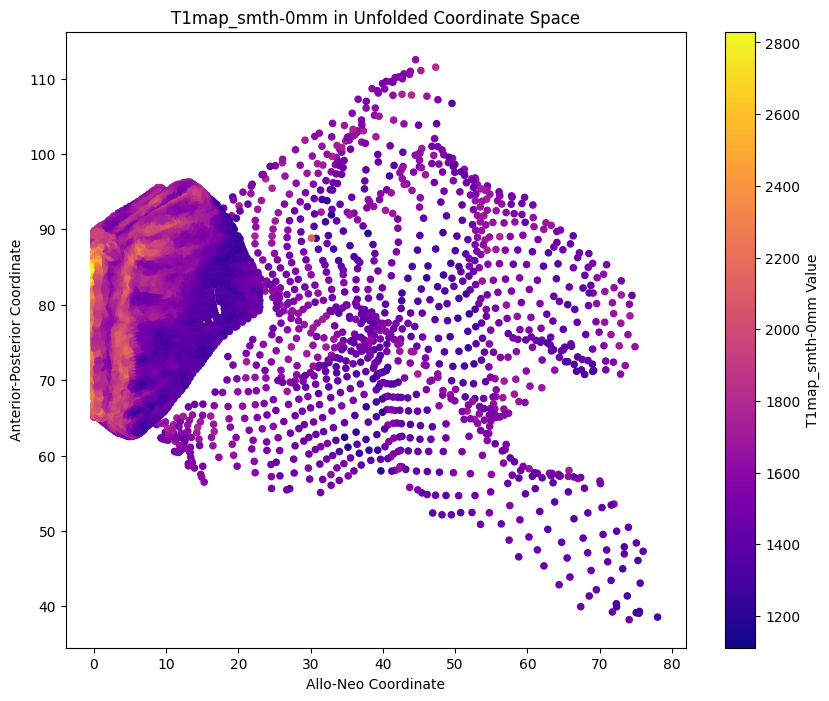

In [ ]:
ap_coords = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lbl_AP_masked-13Feb2026.label.gii"
an_coords = "/host/verges/tank/data/daniel/04_inVivoHistology/code/resources/13Feb/stitch_lbl_AlloNeo_masked-13Feb2026.label.gii"

ft_map = "/host/verges/tank/data/daniel/04_inVivoHistology/data/PNI/sub-PNE042_ses-a1/maps/sub-PNE042_ses-a1_hemi-L_12Feb2026-1304_equivol-1of16_map-T1map_smth-0mm.func.gii"
visUtils.vis_make_unfold(unfold_x_coords_pth=an_coords, unfold_y_coords_pth=ap_coords, feature_map_pth=ft_map, map_name="T1map_smth-0mm", cmap='plasma')


In [56]:
# counts per df_group
for grp, demo_qc in list_df_groups:
    print(f"Group {grp} has {len(demo_qc)} sessions")
    # summarise sex, age
    sex_counts = demo_qc['sex'].value_counts()
    age_mean = demo_qc['age'].mean()
    age_std = demo_qc['age'].std()
    print(f"Sex distribution in group {grp}:")
    for sex, count in sex_counts.items():
        print(f"\t{sex}: {count}")
    print(f"Age in group {grp}: mean={age_mean:.2f}, std={age_std:.2f}")


Group CTRL has 108 sessions
Sex distribution in group CTRL:
	F: 30
	M: 27
Age in group CTRL: mean=28.69, std=5.32
Group TLE_L has 12 sessions
Sex distribution in group TLE_L:
	M: 6
	F: 6
Age in group TLE_L: mean=35.78, std=8.94
Group TLE_R has 11 sessions
Sex distribution in group TLE_R:
	F: 10
	M: 1
Age in group TLE_R: mean=33.89, std=10.31


In [11]:
ft = nib.load(ft_map)
ft_data = ft.darrays[0].data
print(ft_data.shape)

(8477,)


In [ ]:
importlib.reload(visUtils)
importlib.reload(prjUtils)
importlib.reload(check)
# get bash command to visualize surfaces and volumes

for pt in demo_qc.itertuples():
    uid = pt.UID
    study = pt.study
    ses = pt.SES
    mics_id = pt.MICS_ID
    pni_id = pt.PNI_ID

    if study == '7T':
        id = pni_id
        study_dict = next(sd for sd in study_dicts if sd['studyName'] == 'PNI')
    elif study == '3T':
        id = mics_id
        study_dict = next(sd for sd in study_dicts if sd['studyName'] == 'MICs')
    else:
        print(f"[main] WARNING: study {study} not recognized. Skipping subject {uid}...")
        continue

    mp_root = study_dict['dir_root'] + study_dict['dir_deriv'] + study_dict['dir_mp']
    hu_root = study_dict['dir_root'] + study_dict['dir_deriv'] + study_dict['dir_hu']

    # get paths
    vol_pth = names.get_volPath(study = study_dict, id = id, ses = ses, volName = 'T1map')[0]
    
    if visualization_params['add_stitchedSurf'] or visualization_params['add_sampledSurfs']:
        dir_subjectData = os.path.join(prjUtils.get_path_data(dirs_project, studyName = study_dict['studyName'], id = id, ses = ses), 'surfs')
        prjUtils.make_dir(dir_subjectData)
        print(f"Subject data directory: {dir_subjectData}")
    
    surface_combinations = prjUtils.iterate_labels(analysis_params['lbls_surfs'])
    print(surface_combinations)
    
    for surfs, lbls in surface_combinations:
        surf_pths = []
        ctx_surf = surfs[0]
        hipp_surf = surfs[1]

        ctx_lbl = lbls[0]
        hipp_lbl = lbls[1]

        print(f"Combination: {ctx_surf}-{ctx_lbl} | {hipp_surf}-{hipp_lbl}")

        mp_surfs = names.get_surf_pth(root = mp_root, sub = id, ses = ses, lbl=ctx_lbl, surf=ctx_surf, verbose = False)
        hu_surfs = names.get_surf_pth(root = hu_root, sub = id, ses = ses, lbl=hipp_lbl, surf=hipp_surf, verbose = False)
        print(f"MP surfaces: {mp_surfs}")
        print(f"HU surfaces: {hu_surfs}")
        surf_pths += mp_surfs
        surf_pths += hu_surfs

        if visualization_params['add_stitchedSurf']:
            print("\tGetting stitched surf names...")
            stched_name_l, stched_name_r = prjUtils.get_names_stitchSurf(id=id, ses=ses, ctx_lbl=ctx_lbl, ctx_surf=ctx_surf, hipp_lbl=hipp_lbl, hipp_surf=hipp_surf)
            
            if visualization_params['mask']['applied']:
                print(f"\t\tTaking stitched surfaces with mask applied: {visualization_params['mask']['suffix']}")
                stched_name_l = stched_name_l.replace(".surf.gii", f"_mask-{visualization_params['mask']['suffix']}.gii")
                stched_name_r = stched_name_r.replace(".surf.gii", f"_mask-{visualization_params['mask']['suffix']}.gii")
            print(f"\t\tStitched names: {stched_name_l}, {stched_name_r}")
            surf_pths += [os.path.join(dir_subjectData, stched_name_l), 
                        os.path.join(dir_subjectData, stched_name_r)]

        if visualization_params['add_sampledSurfs']:
            print("\tGetting sampled surf names...")
            outNamePrefix = f"{gen.fmt_id_ses(id,ses)}"
            baseNames = [f"{outNamePrefix}_hemi-L_{visualization_params['equiVol_str']}",
                         f"{outNamePrefix}_hemi-R_{visualization_params['equiVol_str']}"]
            
            # search for all files containing either base name in the dir_subjectData
            for bn in baseNames:
                print(f"\t\tLooking for basename: {bn}")
                matched_files = [f for f in os.listdir(dir_subjectData) if bn in f and f"of{analysis_params['nSurfs']}" in f and f.endswith('.surf.gii')]
                print(f"\t\tMatched files {len(matched_files)}: {matched_files}")
                surf_pths += [os.path.join(dir_subjectData, f) for f in matched_files if f"of{analysis_params['nSurfs']}" in f]

    # generate visualization command
    # check that all files exist
    surf_exist = check.check_paths_exist(surf_pths)
    surf_pths = [surf_pth for surf_pth, exist in zip(surf_pths, surf_exist) if exist]
    print(visUtils.getCMD_freeView(surf_pths=surf_pths, vol_pth=vol_pth, 
                                colour = visualization_params['colour']))

        

In [ ]:


# following steps should be able to be performed on data from any source (PNI, MICs, AHEAD, BigBrain, etc.)

# save surfaces generated at different depths to study directory
# stitch cortical and hippocampal surfaces together. NOTE. Jordan code
# remove vertices not in mesial temporal lobe (choose cut-off limit as per Paquola 2020)
# assign each vertex values along anterior-posterior, and allo/neo-cortical axes
# project features onto surfaces


In [ ]:
# analyses

In [ ]:
dir_subjectData = "/host/verges/tank/data/daniel/04_inVivoHistology/data/test/PNI/sub-PNA004_ses-a1"
bn = "sub-PNA004_ses-a1_hemi-R_equivol"
matched_files = [f for f in os.listdir(dir_subjectData) if bn in f]
print(f"Matched files: {matched_files}")

Matched files: []


In [ ]:
os.listdir(dir_subjectData)

['surfs']